##Emotion Token Prepending


## Section 1: Install & Imports

In [1]:
!pip install -q transformers datasets rouge-score nltk sentencepiece accelerate vaderSentiment

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 4.7 MB/s eta 0:00:00


In [2]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

import os, ast, random, json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (BartTokenizer, BartForConditionalGeneration,
                          pipeline, get_linear_schedule_with_warmup)
from torch.optim import AdamW
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from collections import Counter
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4



## Section 2: Mount Drive & Load Data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH      = '/content/drive/MyDrive/NeuralNetworks/Project/Dataset/train.csv'
BASELINE_DIR   = '/content/drive/MyDrive/NeuralNetworks/Project/checkpoints/baseline'
SAVE_DIR       = '/content/drive/MyDrive/NeuralNetworks/Project/checkpoints/EmoToken'
BASELINE_RESULTS_PATH = os.path.join(BASELINE_DIR, 'baseline_results.json')
os.makedirs(SAVE_DIR, exist_ok=True)

MODEL_NAME     = 'facebook/bart-base'
MAX_INPUT_LEN  = 128
MAX_TARGET_LEN = 64
BATCH_SIZE     = 8
GRAD_ACCUM     = 4
EPOCHS         = 5
LR             = 3e-5
WARMUP_STEPS   = 100
SUBSET         = None

Mounted at /content/drive



## Section 3: Data Parsing

In [4]:
import re
EMOTION_MAP = {
    0: "neutral",
    1: "anger",
    2: "disgust",
    3: "fear",
    4: "happiness",
    5: "sadness",
    6: "surprise"
}

def parse_array_string(s):
    return [int(x) for x in s.strip().strip('[]').split()]

def parse_dialog_string(s):
    """
    Extract individual utterances by splitting on the boundary between
    adjacent quoted strings in the serialized list.
    Pattern: end of one quote, whitespace/newline, start of next quote.
    """
    # Normalize
    s = s.strip()
    if s.startswith('['):
        s = s[1:]
    if s.endswith(']'):
        s = s[:-1]
    parts = re.split(r"""['"]\s*\n\s*['"']""", s)

    turns = []
    for part in parts:
        # Strip leading/trailing whitespace and quote characters
        cleaned = part.strip().strip("'\"").strip()
        if cleaned:
            turns.append(cleaned)

    return turns if len(turns) >= 2 else None



def build_pairs(df, context_window=3):
    pairs = []
    for _, row in df.iterrows():
        turns   = parse_dialog_string(row['dialog'])
        emotions = parse_array_string(row['emotion'])
        if turns is None or len(turns) < 2 or len(turns) != len(emotions):
            continue
        for i in range(1, len(turns)):
            ctx   = ' [SEP] '.join(turns[max(0, i - context_window):i])
            pairs.append({
                'context':       ctx,
                'response':      turns[i],
                'emotion':       emotions[i],
                'emotion_label': EMOTION_MAP[emotions[i]]
            })
    return pairs

df_raw = pd.read_csv(DATA_PATH)

all_pairs = build_pairs(df_raw)
random.shuffle(all_pairs)
n = len(all_pairs)
train_pairs = all_pairs[:int(0.8*n)]
val_pairs   = all_pairs[int(0.8*n):int(0.9*n)]
test_pairs  = all_pairs[int(0.9*n):]
print(f'Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}')

Train: 24840 | Val: 3105 | Test: 3106



## Section 4: Add Emotion Special Tokens

We add 7 tokens, one per emotion to the tokenizer vocabulary, then resize the model's embedding matrix to match.

At training time, the decoder input sequence becomes:
```
[EMOTION-HAPPINESS] I think that is a wonderful idea .
```
The model learns to generate responses whose style and content match the prepended emotion token.

In [5]:
# Define the 7 special emotion tokens
EMOTION_TOKENS = {
    emo: f'[EMOTION-{emo.upper()}]'
    for emo in EMOTION_MAP.values()
}

# Load tokenizer and add the new tokens
tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
orig_vocab_size = tokenizer.vocab_size

new_tokens = list(EMOTION_TOKENS.values())
tokenizer.add_special_tokens({'additional_special_tokens': new_tokens})
print(f'Vocab size: {orig_vocab_size} → {len(tokenizer)}')

# Verify tokens are recognized as single tokens (not split)
for label, tok in EMOTION_TOKENS.items():
    ids = tokenizer.encode(tok, add_special_tokens=False)
    print(f'  {tok}: {ids}  (should be a single id)')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Vocab size: 50265 → 50272
  [EMOTION-NEUTRAL]: [50265]  (should be a single id)
  [EMOTION-ANGER]: [50266]  (should be a single id)
  [EMOTION-DISGUST]: [50267]  (should be a single id)
  [EMOTION-FEAR]: [50268]  (should be a single id)
  [EMOTION-HAPPINESS]: [50269]  (should be a single id)
  [EMOTION-SADNESS]: [50270]  (should be a single id)
  [EMOTION-SURPRISE]: [50271]  (should be a single id)


In [6]:
# Load model and resize embeddings to accommodate new tokens
model = BartForConditionalGeneration.from_pretrained(MODEL_NAME)
model.resize_token_embeddings(len(tokenizer))
model = model.to(DEVICE)

print(f'Embedding matrix resized to: {model.model.shared.weight.shape}')

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, use `mean_resizing=False`


Embedding matrix resized to: torch.Size([50272, 768])



## Section 5: Emotion-Conditioned Dataset

The target (decoder input) is prefixed with the emotion token before tokenization.

In [7]:
class EmotionConditionedDataset(Dataset):
    """
    EmoToken: prepend emotion token to the decoder target string.
    The model sees: [EMOTION-HAPPINESS] I think that sounds great .
    and learns to generate responses conditioned on that emotion.
    """
    def __init__(self, pairs, tokenizer, emotion_tokens,
                 max_input_len, max_target_len):
        self.pairs          = pairs
        self.tokenizer      = tokenizer
        self.emotion_tokens = emotion_tokens
        self.max_input_len  = max_input_len
        self.max_target_len = max_target_len

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        pair = self.pairs[idx]
        emo_token = self.emotion_tokens[pair['emotion_label']]

        # Encoder input: dialogue context
        enc = self.tokenizer(
            pair['context'],
            max_length=self.max_input_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        # Decoder target: emotion token + space + response
        conditioned_response = f"{emo_token} {pair['response']}"
        dec = self.tokenizer(
            conditioned_response,
            max_length=self.max_target_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        labels = dec['input_ids'].squeeze()
        labels[labels == self.tokenizer.pad_token_id] = -100

        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         labels,
            'emotion':        pair['emotion'],
            'emotion_label':  pair['emotion_label']
        }

train_dataset = EmotionConditionedDataset(train_pairs, tokenizer, EMOTION_TOKENS, MAX_INPUT_LEN, MAX_TARGET_LEN)
val_dataset   = EmotionConditionedDataset(val_pairs,   tokenizer, EMOTION_TOKENS, MAX_INPUT_LEN, MAX_TARGET_LEN)
test_dataset  = EmotionConditionedDataset(test_pairs,  tokenizer, EMOTION_TOKENS, MAX_INPUT_LEN, MAX_TARGET_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

sample = train_dataset[0]
decoded_label = tokenizer.decode([t for t in sample['labels'] if t != -100])
print('Sample decoder target (first training example):')
print(' ', decoded_label[:120])

Sample decoder target (first training example):
  <s>[EMOTION-NEUTRAL] so by then , you'll be in charge of the whole department .</s>



## Section 6: Training

In [8]:
optimizer = AdamW(model.parameters(), lr=LR, weight_decay=0.01)
total_steps = (len(train_loader) // GRAD_ACCUM) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=WARMUP_STEPS, num_training_steps=total_steps
)

from torch.nn import CrossEntropyLoss

def compute_emotion_weights(pairs, emotion_map, device):
    """
    Compute inverse-frequency weights for each emotion class.
    Rare emotions get higher weight so the model doesn't collapse to neutral.
    """
    counts = Counter(p['emotion'] for p in pairs)
    total  = sum(counts.values())
    n_classes = len(emotion_map)

    weights = torch.zeros(n_classes)
    for idx in range(n_classes):
        count = counts.get(idx, 1)
        weights[idx] = total / (n_classes * count)

    weights = weights / weights.mean()
    print("Emotion weights:")
    for idx, name in emotion_map.items():
        print(f"  {name:12s}: {weights[idx]:.3f}  (count={counts.get(idx,0)})")

    return weights.to(device)

emotion_weights = compute_emotion_weights(train_pairs, EMOTION_MAP, DEVICE)

def train_one_epoch(model, loader, optimizer, scheduler, device, grad_accum, weights=None):
    model.train()
    total_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(tqdm(loader, desc='Training')):
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        if weights is not None:
            logits = outputs.logits
            vocab_weights = torch.ones(logits.size(-1), device=device)
            for idx in range(len(weights)):
                emo_name = EMOTION_MAP[idx]
                emo_tok  = EMOTION_TOKENS[emo_name]
                emo_id   = tokenizer.convert_tokens_to_ids(emo_tok)
                vocab_weights[emo_id] = weights[idx]

            loss_fn = CrossEntropyLoss(
                weight=vocab_weights,
                ignore_index=-100
            )
            loss = loss_fn(
                logits.view(-1, logits.size(-1)),
                labels.view(-1)
            ) / grad_accum
        else:
            loss = outputs.loss / grad_accum

        loss.backward()
        total_loss += loss.item() * grad_accum

        if (step + 1) % grad_accum == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

    return total_loss / len(loader)
def evaluate_loss(model, loader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in tqdm(loader, desc='Validation'):
            outputs = model(
                input_ids=batch['input_ids'].to(device),
                attention_mask=batch['attention_mask'].to(device),
                labels=batch['labels'].to(device)
            )
            total_loss += outputs.loss.item()
    return total_loss / len(loader)

Emotion weights:
  neutral     : 0.007  (count=20564)
  anger       : 0.537  (count=282)
  disgust     : 1.579  (count=96)
  fear        : 3.886  (count=39)
  happiness   : 0.048  (count=3156)
  sadness     : 0.609  (count=249)
  surprise    : 0.334  (count=454)



===== EPOCH 1/5 =====


Training:   0%|          | 0/3105 [00:00<?, ?it/s]

Validation:   0%|          | 0/389 [00:00<?, ?it/s]

Train Loss: 3.0265 | Val Loss: 2.9082


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Training:   0%|          | 0/3105 [00:00<?, ?it/s]

Validation:   0%|          | 0/389 [00:00<?, ?it/s]

Train Loss: 2.3690 | Val Loss: 2.4925


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  --> Saved best model to /content/drive/MyDrive/NeuralNetworks/Project/checkpoints/EmoToken

Best Val Loss: 2.4925


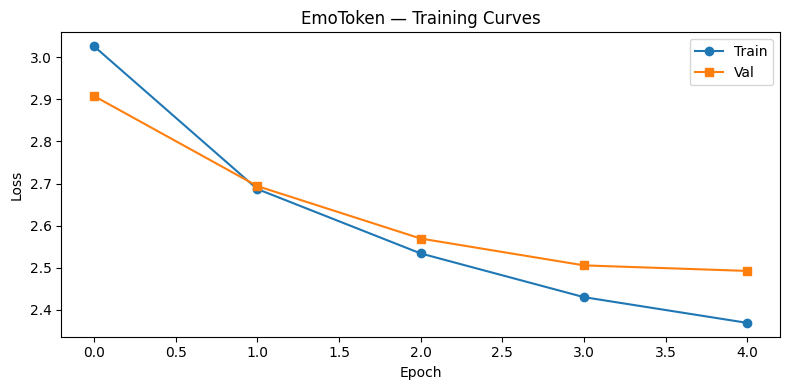

In [9]:
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(1, EPOCHS + 1):
    print(f'\n===== EPOCH {epoch}/{EPOCHS} =====')
    train_loss = train_one_epoch(
    model, train_loader, optimizer, scheduler,
    DEVICE, GRAD_ACCUM, weights=emotion_weights
)
    val_loss   = evaluate_loss(model, val_loader, DEVICE)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    print(f'Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}')
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained(SAVE_DIR)
        tokenizer.save_pretrained(SAVE_DIR)
        print(f'  --> Saved best model to {SAVE_DIR}')

print(f'\nBest Val Loss: {best_val_loss:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(history['train_loss'], label='Train', marker='o')
plt.plot(history['val_loss'],   label='Val',   marker='s')
plt.title('EmoToken — Training Curves')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'training_curves_EmoToken.png'), dpi=150)
plt.show()


## Section 7: Generate Responses

In [10]:
# Load best checkpoint
model = BartForConditionalGeneration.from_pretrained(SAVE_DIR).to(DEVICE)
tokenizer = BartTokenizer.from_pretrained(SAVE_DIR)
model.eval()

def generate_with_emotion(model, tokenizer, pairs, emotion_tokens, device,
                           batch_size=16, max_input_len=128, max_gen_len=64,
                           num_beams=4, no_repeat_ngram_size=3):
    """
    Generate responses conditioned on oracle emotion labels.
    We force the decoder to start with the emotion token by using
    forced_bos_token_id = the emotion token id.
    """
    all_generated = []
    for i in tqdm(range(0, len(pairs), batch_size), desc='Generating'):
        batch_pairs = pairs[i:i + batch_size]
        contexts = [p['context'] for p in batch_pairs]

        enc = tokenizer(
            contexts, max_length=max_input_len,
            padding=True, truncation=True, return_tensors='pt'
        ).to(device)

        batch_generated = []
        for j, pair in enumerate(batch_pairs):
            emo_tok   = emotion_tokens[pair['emotion_label']]
            emo_id    = tokenizer.convert_tokens_to_ids(emo_tok)

            single_enc = {
                'input_ids':      enc['input_ids'][j:j+1],
                'attention_mask': enc['attention_mask'][j:j+1]
            }
            with torch.no_grad():
                out = model.generate(
                    **single_enc,
                    max_new_tokens=max_gen_len,
                    num_beams=num_beams,
                    no_repeat_ngram_size=no_repeat_ngram_size,
                    forced_bos_token_id=emo_id,
                    early_stopping=True
                )
            decoded = tokenizer.decode(out[0], skip_special_tokens=True)
            batch_generated.append(decoded)

        all_generated.extend(batch_generated)
    return all_generated

generated = generate_with_emotion(model, tokenizer, test_pairs, EMOTION_TOKENS, DEVICE)
references = [p['response'] for p in test_pairs]

print('\n--- Sample outputs ---')
for i in range(4):
    print(f'\n[{i+1}] Emotion  : {test_pairs[i]["emotion_label"]}')
    print(f'    Context  : {test_pairs[i]["context"][:80]}...')
    print(f'    Reference: {references[i]}')
    print(f'    Generated: {generated[i]}')

Loading weights:   0%|          | 0/260 [00:00<?, ?it/s]

Generating:   0%|          | 0/195 [00:00<?, ?it/s]


--- Sample outputs ---

[1] Emotion  : happiness
    Context  : Oh . I just wanted you to shut up . You were off-key anyway . Let me see that ! ...
    Reference: What a cool see-through blue ! How do you wear this thing ?
    Generated:  Oh , no ! I'm so sorry ! I didn't mean to be rude !

[2] Emotion  : surprise
    Context  : Don ’ t be intimidated . There is a lot to sign , but I will explain everything ...
    Reference: There are a lot of papers !
    Generated:  Thank you very much .

[3] Emotion  : neutral
    Context  : Thanks , good to meet you , too . [SEP] You had a long flight , you must be tire...
    Reference: Oh , sorry to hear that . But , don worry ! Taiwan has plenty of great things to eat . First , lets get you to the hotel .
    Generated:  Really ? I didn ’ t like the food , either .

[4] Emotion  : neutral
    Context  : Those are today ’ s top stories . Now let ’ s go to John for the weather . John ...
    Reference: I ’ m afraid we ’ re in for a rough weekend


## Section 8: Evaluation

### 8a. Standard metrics (BLEU-4, ROUGE-L, METEOR, Distinct)

In [11]:
def compute_bleu4(references, hypotheses):
    ref_tok = [[nltk.word_tokenize(r.lower())] for r in references]
    hyp_tok = [nltk.word_tokenize(h.lower()) for h in hypotheses]
    return corpus_bleu(ref_tok, hyp_tok, weights=(0.25,)*4,
                       smoothing_function=SmoothingFunction().method1) * 100

def compute_rougeL(references, hypotheses):
    sc = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    return np.mean([sc.score(r, h)['rougeL'].fmeasure
                    for r, h in zip(references, hypotheses)]) * 100

def compute_meteor(references, hypotheses):
    return np.mean([
        meteor_score([nltk.word_tokenize(r.lower())], nltk.word_tokenize(h.lower()))
        for r, h in zip(references, hypotheses)
    ]) * 100

def compute_distinct(hypotheses, n=2):
    all_ng = []
    for h in hypotheses:
        toks = nltk.word_tokenize(h.lower())
        all_ng.extend(tuple(toks[i:i+n]) for i in range(len(toks)-n+1))
    return (len(set(all_ng)) / len(all_ng) * 100) if all_ng else 0.0

bleu4  = compute_bleu4(references, generated)
rougeL = compute_rougeL(references, generated)
meteor = compute_meteor(references, generated)
dist1  = compute_distinct(generated, 1)
dist2  = compute_distinct(generated, 2)

print(f'BLEU-4:     {bleu4:.2f}')
print(f'ROUGE-L:    {rougeL:.2f}')
print(f'METEOR:     {meteor:.2f}')
print(f'Distinct-1: {dist1:.2f}')
print(f'Distinct-2: {dist2:.2f}')

BLEU-4:     2.12
ROUGE-L:    13.53
METEOR:     12.94
Distinct-1: 6.17
Distinct-2: 24.85


### 8b. Emotion Alignment — Pretrained Classifier

We use `j-hartmann/emotion-english-distilroberta-base`, a small, fast DistilRoBERTa fine-tuned on 6 emotion categories. It maps well enough to DailyDialog's 7 categories for alignment measurement.

**Metric:** for each generated response, we predict its emotion and check whether it matches the target emotion label. We report accuracy and macro-F1.

In [12]:
emotion_classifier = pipeline(
    'text-classification',
    model='j-hartmann/emotion-english-distilroberta-base',
    top_k=1,
    device=0 if torch.cuda.is_available() else -1
)

# The classifier uses Ekman's 6 emotions + neutral; map to DailyDialog's 7
# j-hartmann labels: anger, disgust, fear, joy, neutral, sadness, surprise
CLASSIFIER_TO_DAILYDIALOG = {
    'anger':   'anger',
    'disgust': 'disgust',
    'fear':    'fear',
    'joy':     'happiness',
    'neutral': 'neutral',
    'sadness': 'sadness',
    'surprise':'surprise'
}

def predict_emotions(texts, classifier, batch_size=32):
    """Run classifier over texts in batches, return list of DailyDialog emotion labels."""
    results = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Classifying emotions'):
        batch = texts[i:i+batch_size]
        batch = [t[:512] for t in batch]
        preds = classifier(batch)
        for pred in preds:
            label = pred[0]['label'].lower()
            results.append(CLASSIFIER_TO_DAILYDIALOG.get(label, 'neutral'))
    return results

# Predict emotions of generated responses
predicted_emotions = predict_emotions(generated, emotion_classifier)
target_emotions    = [p['emotion_label'] for p in test_pairs]


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/329M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/294 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Classifying emotions:   0%|          | 0/98 [00:00<?, ?it/s]

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


In [14]:
from sklearn.metrics import accuracy_score, f1_score, classification_report

emotion_accuracy = accuracy_score(target_emotions, predicted_emotions) * 100
emotion_f1       = f1_score(target_emotions, predicted_emotions,
                            average='macro', zero_division=0) * 100

print(f'Emotion Alignment Accuracy: {emotion_accuracy:.2f}%')
print(f'Emotion Macro-F1:           {emotion_f1:.2f}%')
print('\nPer-class breakdown:')
print(classification_report(target_emotions, predicted_emotions, zero_division=0))

Emotion Alignment Accuracy: 33.00%
Emotion Macro-F1:           12.91%

Per-class breakdown:
              precision    recall  f1-score   support

       anger       0.00      0.00      0.00        41
     disgust       0.00      0.00      0.00         8
        fear       0.01      0.17      0.02         6
   happiness       0.20      0.45      0.27       375
     neutral       0.91      0.32      0.47      2577
     sadness       0.05      0.33      0.08        43
    surprise       0.03      0.52      0.06        56

    accuracy                           0.33      3106
   macro avg       0.17      0.25      0.13      3106
weighted avg       0.78      0.33      0.42      3106



### 8c. VADER Sentiment Coherence

For each (context, generated response) pair we compute the VADER compound sentiment score of both. Sentiment coherence measures how often context and response share the same valence (positive / negative / neutral).

In [13]:
vader = SentimentIntensityAnalyzer()

def vader_label(text):
    """Classify text as positive, negative, or neutral using VADER compound score."""
    score = vader.polarity_scores(text)['compound']
    if score >= 0.05:  return 'positive'
    if score <= -0.05: return 'negative'
    return 'neutral'

# Get last turn of context (the user utterance) and the generated response
context_sentiments  = [vader_label(p['context'].split('[SEP]')[-1].strip()) for p in test_pairs]
response_sentiments = [vader_label(g) for g in generated]

# Sentiment coherence = fraction of pairs where context and response share the same valence
sentiment_coherence = np.mean([c == r for c, r in zip(context_sentiments, response_sentiments)]) * 100

print(f'VADER Sentiment Coherence: {sentiment_coherence:.2f}%')
print(f'  (Context sentiment dist : {Counter(context_sentiments)})')
print(f'  (Response sentiment dist: {Counter(response_sentiments)})')

VADER Sentiment Coherence: 49.94%
  (Context sentiment dist : Counter({'positive': 1636, 'neutral': 999, 'negative': 471}))
  (Response sentiment dist: Counter({'positive': 1652, 'neutral': 958, 'negative': 496}))



## Section 9: Comparison Table

In [16]:
with open(BASELINE_RESULTS_PATH) as f:
    baseline = json.load(f)

EmoToken = {
    'Model':             'EmoToken (token prepend)',
    'BLEU-4':            round(bleu4, 2),
    'ROUGE-L':           round(rougeL, 2),
    'METEOR':            round(meteor, 2),
    'Distinct-1':        round(dist1, 2),
    'Distinct-2':        round(dist2, 2),
    'Emotion Acc (%)':   round(emotion_accuracy, 2),
    'Emotion F1 (%)':    round(emotion_f1, 2),
    'Sentiment Coh (%)': round(sentiment_coherence, 2),
}

results_path = os.path.join(SAVE_DIR, 'EmoToken_results.json')
with open(results_path, 'w') as f:
    json.dump(EmoToken, f, indent=2)

metrics = ['BLEU-4', 'ROUGE-L', 'METEOR', 'Distinct-1', 'Distinct-2',
           'Emotion Acc (%)', 'Emotion F1 (%)', 'Sentiment Coh (%)']

print('\n' + '='*65)
print(f'  COMPARISON: Baseline vs EmoToken (Token Prepending)')
print('='*65)
print(f'{"Metric":<22} {"Baseline":>12} {"EmoToken":>12} {"Δ":>8}')
print('-'*65)
for m in metrics:
    base_val = baseline.get(m, 'N/A')
    s1_val   = EmoToken.get(m, 'N/A')
    if isinstance(base_val, float) and isinstance(s1_val, float):
        delta = s1_val - base_val
        arrow = '↑' if delta > 0 else ('↓' if delta < 0 else '=')
        print(f'{m:<22} {base_val:>12.2f} {s1_val:>12.2f} {arrow}{abs(delta):>6.2f}')
    else:
        print(f'{m:<22} {str(base_val):>12} {str(s1_val):>12} {"":>8}')


  COMPARISON: Baseline vs EmoToken (Token Prepending)
Metric                     Baseline     EmoToken        Δ
-----------------------------------------------------------------
BLEU-4                         3.06         2.12 ↓  0.94
ROUGE-L                       14.27        13.53 ↓  0.74
METEOR                        14.24        12.94 ↓  1.30
Distinct-1                    10.62         6.17 ↓  4.45
Distinct-2                    36.10        24.85 ↓ 11.25
Emotion Acc (%)                 N/A         33.0         
Emotion F1 (%)                  N/A        12.91         
Sentiment Coh (%)               N/A        49.94         
